In [2]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [3]:
df = pd.read_csv(r'D:\churn project telco\telecom_customer_churn.csv')

In [4]:
# 2. Create Target Variable
# ==================================

# Clean target column first
df["Customer Status"] = df["Customer Status"].str.strip()

# Drop rows where target is missing
df = df[df["Customer Status"].notna()]

# Create binary churn target
df["Churn"] = df["Customer Status"].map({
    "Churned": 1,
    "Stayed": 0,
    "Joined": 0
})

# Ensure no NaN in target
df = df[df["Churn"].notna()]


In [5]:
# 3. Drop Leakage & Irrelevant Columns
# ==================================

columns_to_drop = [
    "Customer ID",
    "City",
    "Zip Code",
    "Latitude",
    "Longitude",
    "Churn Category",
    "Churn Reason",
    "Customer Status"
]

In [6]:
df.drop(columns=columns_to_drop, inplace=True)


In [7]:
# 4. Handle Missing Values
# ==================================

df.fillna(df.median(numeric_only=True), inplace=True)

In [8]:
# 5. Define Features & Target
# ==================================

X = df.drop("Churn", axis=1)
y = df["Churn"]

categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

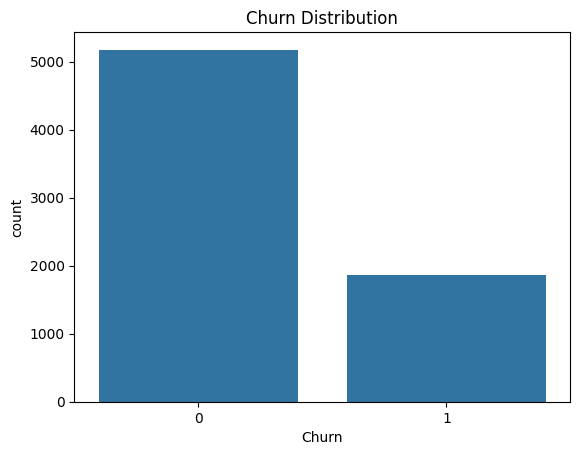

In [9]:
# 1️⃣ Churn Distribution (Very Important)

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()


In [10]:
# 6. Preprocessing
# ==================================

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [11]:
# 7. Model Pipeline
# ==================================

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ))
])

In [12]:
# 8. Train Test Split
# ==================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [13]:
# ==================================
# 9. Train Model
# ==================================

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [14]:
# 10. Evaluation
# ==================================

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("\nROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))



ROC-AUC: 0.891659562375675

Confusion Matrix:
 [[950  85]
 [160 214]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.92      0.89      1035
           1       0.72      0.57      0.64       374

    accuracy                           0.83      1409
   macro avg       0.79      0.75      0.76      1409
weighted avg       0.82      0.83      0.82      1409



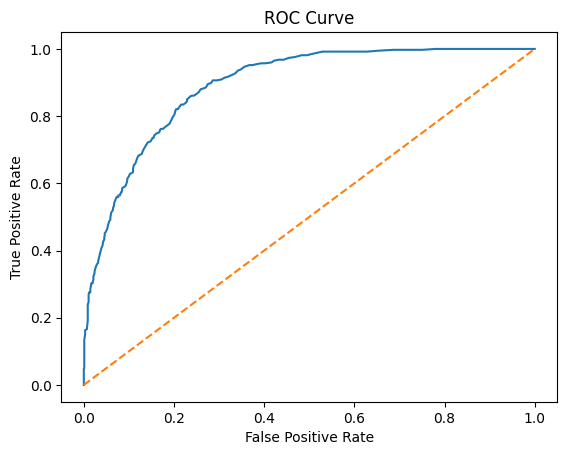

In [15]:
# 2️⃣ ROC Curve

from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()


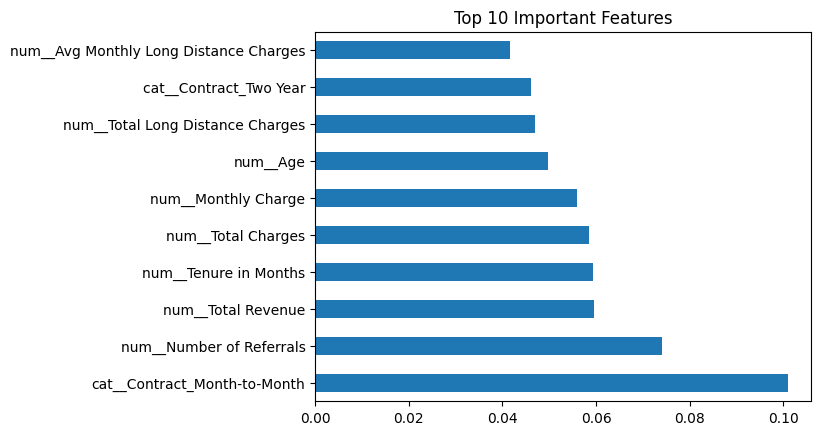

In [16]:
#  Feature Importance (Random Forest)

import numpy as np

importances = model.named_steps["classifier"].feature_importances_
features = model.named_steps["preprocessor"].get_feature_names_out()

feat_importance = pd.Series(importances, index=features)
feat_importance.sort_values(ascending=False).head(10).plot(kind="barh")
plt.title("Top 10 Important Features")
plt.show()


In [17]:
# 11. Save Model
# ==================================

joblib.dump(model, "churn_model.pkl")

print("\nModel saved successfully!")


Model saved successfully!


In [18]:
import joblib

model = joblib.load("churn_model.pkl")

print(type(model))


<class 'sklearn.pipeline.Pipeline'>


In [19]:
churn_rate = df["Churn"].mean()
print("Overall Churn Rate:", round(churn_rate * 100, 2), "%")
joblib.dump(churn_rate, "churn_rate.pkl")


Overall Churn Rate: 26.54 %


['churn_rate.pkl']

In [20]:
df["churn_probability"] = model.predict_proba(X)[:,1]
df["revenue_at_risk"] = df["churn_probability"] * df["Monthly Charge"]

print("Total Revenue At Risk:", round(df["revenue_at_risk"].sum(),2))


Total Revenue At Risk: 135776.06


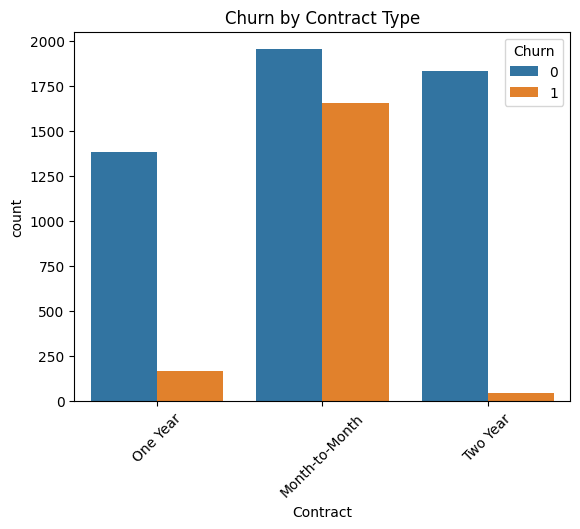

In [21]:
 # Churn by Contract Type
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn by Contract Type")
plt.xticks(rotation=45)
plt.show()


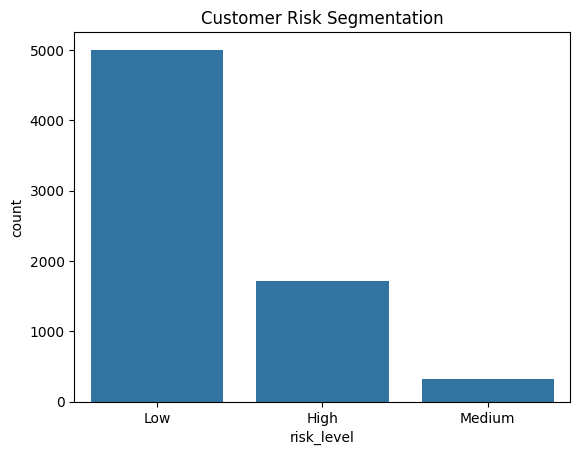

In [22]:
df["risk_level"] = df["churn_probability"].apply(
    lambda x: "Low" if x < 0.3 else ("Medium" if x < 0.6 else "High")
)

sns.countplot(x="risk_level", data=df)
plt.title("Customer Risk Segmentation")
plt.show()
